In [14]:
import pandas as pd

data = pd.read_csv('/scratch2/mlavechin/phorec/phonetically_transcribed_pairs/utterances2.csv', sep='\t')

/tmp/ipykernel_3323283/3687081856.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/scratch2/mlavechin/phorec/phonetically_transcribed_pairs/utterances2.csv', sep='\t')


       speaker_type  speaker_role speaker  \
0              KCHI  Target_Child     CHI   
1              KCHI  Target_Child     CHI   
2              KCHI  Target_Child     CHI   
3              KCHI  Target_Child     CHI   
4              KCHI  Target_Child     CHI   
...             ...           ...     ...   
603903         KCHI  Target_Child     CHI   
603904         KCHI  Target_Child     CHI   
603905         KCHI  Target_Child     CHI   
603906         KCHI  Target_Child     CHI   
603907         KCHI  Target_Child     CHI   

                                       content                   phones  \
0                                        olá .                     ɐˈjɐ   
1                                        olá .                     ˈ*aː   
2                                        olá .                    ɐˈlaː   
3                                        olá .                     ɐˈna   
4                                        olá .                     ɐˈ*a   
...      

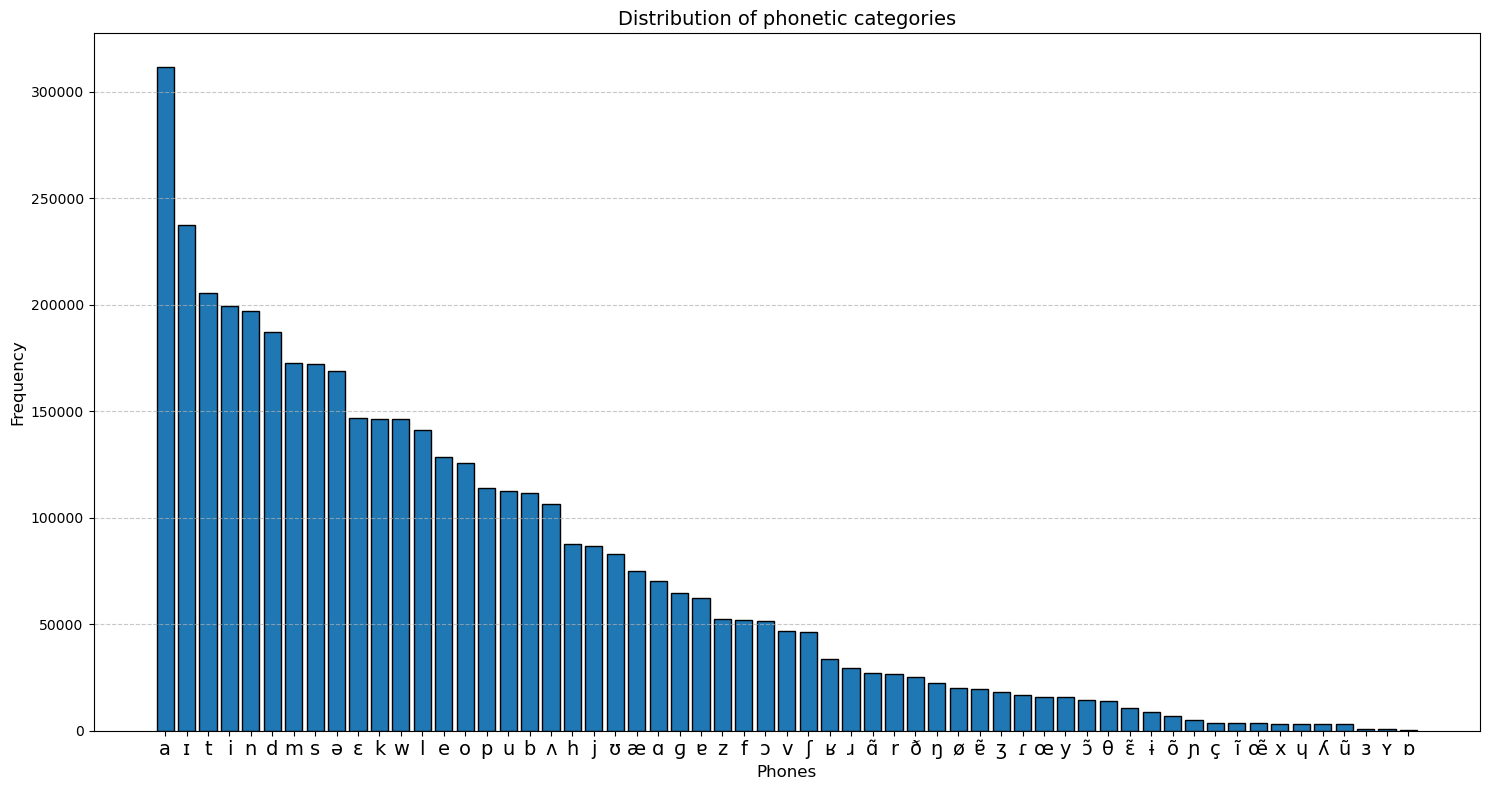

Total unique phones: 59

Phone counts:
a: 311,759
ɪ: 237,207
t: 205,441
i: 199,248
n: 196,851
d: 187,170
m: 172,647
s: 172,204
ə: 168,709
ɛ: 146,812
k: 146,495
w: 146,355
l: 141,176
e: 128,349
o: 125,498
p: 114,019
u: 112,359
b: 111,538
ʌ: 106,323
h: 87,771
j: 86,493
ʊ: 82,783
æ: 74,993
ɑ: 70,414
ɡ: 64,774
ɐ: 62,308
z: 52,601
f: 52,154
ɔ: 51,674
v: 46,641
ʃ: 46,503
ʁ: 33,857
ɹ: 29,312
ɑ̃: 26,981
r: 26,634
ð: 25,308
ŋ: 22,508
ø: 19,861
ɐ̃: 19,510
ʒ: 18,127
ɾ: 16,541
œ: 16,047
y: 16,019
ɔ̃: 14,635
θ: 14,175
ɛ̃: 10,615
ɨ: 8,582
õ: 7,124
ɲ: 5,098
ç: 3,634
ĩ: 3,577
œ̃: 3,429
x: 3,230
ɥ: 3,102
ʎ: 3,072
ũ: 2,999
ɜ: 959
ʏ: 766
ɒ: 431


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


all_phones = []
for phone_sequence in data['simplified_phones']:
    if isinstance(phone_sequence, str):
        phones = phone_sequence.split()
        all_phones.extend(phones)

phone_counts = Counter(all_phones)

most_common = phone_counts.most_common(100)

plt.figure(figsize=(15, 8))
plt.grid(axis='y', linestyle='--', alpha=0.7)

phones, counts = zip(*most_common)

bars = plt.bar(range(len(phones)), counts, edgecolor='black')

plt.xlabel('Phones', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of phonetic categories', fontsize=14)

plt.xticks(range(len(phones)), phones, ha='center', fontsize=14)

plt.tight_layout()
plt.savefig('/scratch2/mlavechin/phorec/analysis/phoneme_distrib.png', dpi=300)
plt.show()

# Print the total number of unique phones
print(f"Total unique phones: {len(phone_counts)}")

# Print counts for all phones (or you can limit to top N if there are too many)
print("\nPhone counts:")
for phone, count in most_common:
    print(f"{phone}: {count:,}")


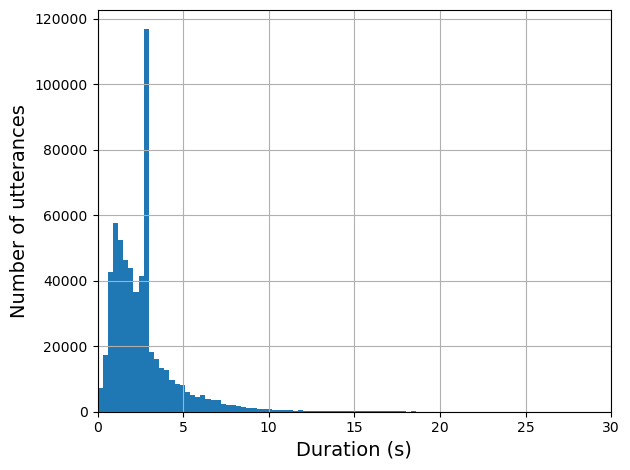

In [45]:
data = data[data['duration'] < 30]
data['duration'] = (data['offset'] - data['onset'])/1000
data['duration'].hist(bins=100)
plt.ylabel("Number of utterances", fontsize=14)
plt.xlabel("Duration (s)", fontsize=14)
plt.xlim(0,30)
plt.tight_layout()
plt.savefig('/scratch2/mlavechin/phorec/analysis/duration_distrib.png', dpi=300)

In [50]:
data[data.duration == 3]['corpus'].unique()

array(['CCF', 'Chiat', 'ChildL2', 'Cummings', 'Davis', 'Granada', 'Grimm',
       'KernFrench', 'Lyon', 'McAllister', 'Menn', 'Paris', 'Penney',
       'PereiraFreitas', 'PhonoDis', 'Preston', 'Providence', 'Ramalho',
       'Seine-Marne', 'Twins-Brazil', 'Yamaguchi'], dtype=object)

In [39]:
data_sorted = data.sort_values('duration')
data_sorted[['simplified_phones', 'duration', 'audio_path']]

,simplified_phones,duration,audio_path
362,u k ɐ,0.001,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
361,t a a,0.001,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
243898,m,0.001,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
243899,j a ʌ,0.001,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
243870,a t a t a a t a,0.001,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
...,...,...,...
241832,k o k ɔ,29.932,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
470900,m ɑ m i,29.940,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
391284,ə p i k,29.944,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...
244557,ɛ p a ʃ ɛ ʃ e p a t u e b o ʒ ɛ j o b i o ʌ e ...,29.960,/scratch1/data/raw_data/CLEAR_ASR/IN_PREP/down...


In [11]:
data[

Index(['speaker_type', 'speaker_role', 'speaker', 'content', 'phones', 'onset',
       'offset', 'transcript_path', 'audio_path', 'age', 'language', 'gender',
       'ses', 'speaker_group', 'file_design', 'file_group', 'file_activity',
       'corpus', 'database', 'duration', 'age_months', 'simplified_phones'],
      dtype='object')